# **Аналіз даних, відбір ознак, попередня обробка**
Датасет: https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset

In [15]:
import warnings
from IPython.display import Image, display
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, TargetEncoder,
                                   FunctionTransformer, OrdinalEncoder)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
DATA = Path("./dataset/raw/AmesHousing.csv")
OUT = Path("./dataset/prepared")
FIG, TAB = OUT / "figures", OUT / "tables"
for p in (FIG, TAB, OUT / "processed"):
    p.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})


def savefig(name):
    plt.savefig(FIG / name)
    plt.close()


def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))


# 1. **Структура**
2930 рядків × 82 колонки: 39 числових (28 int, 11 float) і 43 текстових. Дублікатів немає, `PID` унікальний.

Розмір: (2930, 82)
Дублікати рядків: 0 | дублікати PID: 0
Пам'ять, МБ: 7.54
str        43
int64      28
float64    11

Числових колонок: 39, категоріальних: 43
                feature_absent_NA  true_missing  true_missing_pct  absent_pct
Lot Frontage                    0           490             16.72        0.00
Garage Yr Blt                   0           159              5.43        0.00
Mas Vnr Type                    0            23              0.78        0.00
Mas Vnr Area                    0            23              0.78        0.00
Bsmt Exposure                  79             4              0.14        2.70
Garage Finish                 157             2              0.07        5.36
BsmtFin Type 2                 79             2              0.07        2.70
Bsmt Full Bath                  0             2              0.07        0.00
Bsmt Half Bath                  0             2              0.07        0.00
Garage Qual                   158             1             

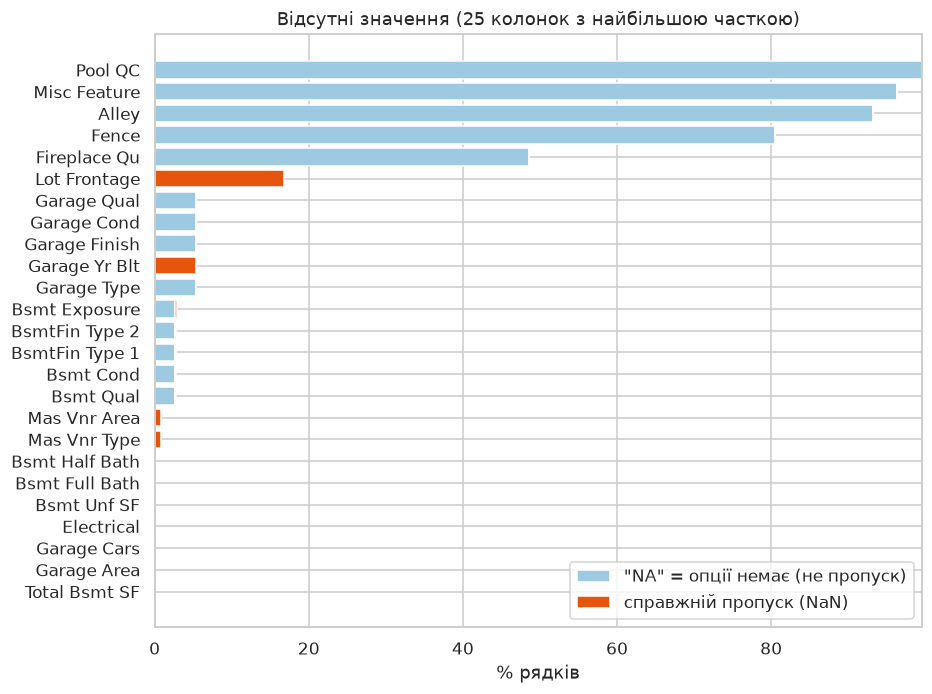

In [16]:
raw = pd.read_csv(DATA, keep_default_na=False, na_values=[""])

print("Розмір:", raw.shape)
print("Дублікати рядків:", raw.duplicated().sum(), "| дублікати PID:", raw["PID"].duplicated().sum())
print("Пам'ять, МБ:", round(raw.memory_usage(deep=True).sum() / 1e6, 2))
print(raw.dtypes.astype(str).value_counts().to_string())

num_raw = raw.select_dtypes(include="number").columns.tolist()
cat_raw = raw.select_dtypes(exclude="number").columns.tolist()
print(f"\nЧислових колонок: {len(num_raw)}, категоріальних: {len(cat_raw)}")

schema = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "example": [raw[c].iloc[0] for c in raw.columns],
})
schema.to_csv(TAB / "01_schema.csv")

# Два різні типи "відсутності"
absent = (raw[cat_raw] == "NA").sum()
missing = pd.DataFrame({
    "feature_absent_NA": absent.reindex(raw.columns).fillna(0).astype(int),
    "true_missing": raw.isna().sum(),
})
missing = missing[(missing > 0).any(axis=1)]
missing["true_missing_pct"] = (missing["true_missing"] / len(raw) * 100).round(2)
missing["absent_pct"] = (missing["feature_absent_NA"] / len(raw) * 100).round(2)
missing = missing.sort_values(["true_missing", "feature_absent_NA"], ascending=False)
missing.to_csv(TAB / "02_missing.csv")
print(missing.to_string())

fig, ax = plt.subplots(figsize=(9, 7))
m = missing.sort_values("true_missing", ascending=True).tail(30)
m2 = missing.assign(total=missing.true_missing + missing.feature_absent_NA).sort_values("total").tail(25)
ax.barh(m2.index, m2["feature_absent_NA"] / len(raw) * 100, label='"NA" = опції немає (не пропуск)', color="#9ecae1")
ax.barh(m2.index, m2["true_missing"] / len(raw) * 100, left=m2["feature_absent_NA"] / len(raw) * 100,
        label="справжній пропуск (NaN)", color="#e6550d")
ax.set_xlabel("% рядків")
ax.set_title("Відсутні значення (25 колонок з найбільшою часткою)")
ax.legend(loc="lower right")
savefig("01_missing.png")
display(Image(filename=str(FIG / "01_missing.png")))

# 2. Підготовка
У датасеті NA означає, що така опція відсутня — тобто немає басейну/гаражу/підвалу. Тому цю опцію залишаємо, як NA.
* `Order`, `PID` — ідентифікатори → видаляємо.
* `Garage Yr Blt` — видаляємо: 159 структурних пропусків (немає гаража), корелює з `Year Built` (~0.84) і містить помилку (рік 2207).
* "Немає підвалу/гаража/мурування" → числові пропуски = 0.
* Ординальні ознаки (Ex>Gd>TA>Fa>Po>NA тощо) → цілі числа за фіксованою шкалою.
* `MS SubClass` (код класу будинку) і `Mo Sold` (місяць) — це номінальні категорії, хоч і записані числами → у рядки.
* Нові ознаки: вік будинку, вік ремонту, загальна площа, кількість ванних, площа веранд.

In [17]:
QUAL = {"NA": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ORDINAL = {
    **{c: QUAL for c in ["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Heating QC",
                         "Kitchen Qual", "Fireplace Qu", "Garage Qual", "Garage Cond", "Pool QC"]},
    "Bsmt Exposure": {"NA": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFin Type 1": {"NA": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFin Type 2": {"NA": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "Garage Finish": {"NA": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Lot Shape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "Land Slope": {"Sev": 1, "Mod": 2, "Gtl": 3},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "Paved Drive": {"N": 0, "P": 1, "Y": 2},
    "Central Air": {"N": 0, "Y": 1},
    "Street": {"Grvl": 0, "Pave": 1},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
}
ZERO_IF_NO_FEATURE = ["Mas Vnr Area", "Bsmt Full Bath", "Bsmt Half Bath", "BsmtFin SF 1", "BsmtFin SF 2",
                      "Bsmt Unf SF", "Total Bsmt SF", "Garage Cars", "Garage Area"]


def engineer(df):
    d = df.drop(columns=["Order", "PID", "Garage Yr Blt"]).copy()
    for c in ZERO_IF_NO_FEATURE:
        d[c] = d[c].fillna(0)
    d["Mas Vnr Type"] = d["Mas Vnr Type"].fillna("None")
    d["MS SubClass"] = d["MS SubClass"].astype(str)
    d["Mo Sold"] = d["Mo Sold"].astype(str)
    for c, mapping in ORDINAL.items():
        before = d[c].isna().sum()
        d[c] = d[c].map(mapping)
        # жодна реальна категорія не має загубитися при мапінгу
        assert d[c].isna().sum() == before, f"Невідомі значення у {c}"
    d["House_Age"] = d["Yr Sold"] - d["Year Built"]
    d["Remod_Age"] = d["Yr Sold"] - d["Year Remod/Add"]
    d["Total_SF"] = d["Total Bsmt SF"] + d["1st Flr SF"] + d["2nd Flr SF"]
    d["Total_Bath"] = (d["Full Bath"] + 0.5 * d["Half Bath"]
                       + d["Bsmt Full Bath"] + 0.5 * d["Bsmt Half Bath"])
    d["Porch_SF"] = d["Open Porch SF"] + d["Enclosed Porch"] + d["3Ssn Porch"] + d["Screen Porch"]
    return d


df = engineer(raw)
TARGET = "SalePrice"
NOM_COLS = df.select_dtypes(exclude="number").columns.tolist()
NUM_COLS = [c for c in df.select_dtypes(include="number").columns if c != TARGET]
print(f"Після підготовки: {len(NUM_COLS)} числових/ординальних, {len(NOM_COLS)} номінальних")
print("Справжніх пропусків залишилось:")
print(df.isna().sum()[df.isna().sum() > 0].to_string())

Після підготовки: 59 числових/ординальних, 24 номінальних
Справжніх пропусків залишилось:
Lot Frontage      490
Bsmt Qual           1
Bsmt Cond           1
Bsmt Exposure       4
BsmtFin Type 1      1
BsmtFin Type 2      2
Electrical          1
Garage Finish       2
Garage Qual         1
Garage Cond         1


# 3. Розбиття train / validation / test (70 / 15 / 15)
Стратифікуємо за децилями ціни, щоб розподіл цільової змінної був схожим у всіх трьох частинах. З цього моменту test не використовується ні для чого, крім одного фінального вимірювання.

In [18]:
bins = pd.qcut(df[TARGET], 10, labels=False)
train_val, test = train_test_split(df, test_size=0.15, random_state=SEED, stratify=bins)
bins_tv = pd.qcut(train_val[TARGET], 10, labels=False)
train, val = train_test_split(train_val, test_size=0.15 / 0.85, random_state=SEED, stratify=bins_tv)

out_mask = (train["Gr Liv Area"] > 4000) & (train[TARGET] < 300000)
print("Викидів видалено з train:", int(out_mask.sum()))
train = train[~out_mask]

print({k: len(v) for k, v in {"train": train, "val": val, "test": test}.items()})
print(pd.DataFrame({k: v[TARGET].describe() for k, v in
                    {"train": train, "val": val, "test": test}.items()}).round(0).to_string())

y_tr, y_va, y_te = (np.log(x[TARGET]) for x in (train, val, test))

Викидів видалено з train: 1
{'train': 2049, 'val': 440, 'test': 440}
          train       val      test
count    2049.0     440.0     440.0
mean   180912.0  181402.0  179640.0
std     80391.0   80875.0   76732.0
min     13100.0   34900.0   12789.0
25%    129000.0  130375.0  129875.0
50%    160000.0  160500.0  160250.0
75%    214000.0  212625.0  213500.0
max    755000.0  610000.0  556581.0


# 4. Первинний аналіз (на train): статистики та розподіли

                      mean       50%       std      min       max   skew
Lot Frontage         68.98      68.0     23.18     21.0     313.0   1.21
Lot Area          10188.80    9453.0   8756.53   1300.0  215245.0  13.02
Street                1.00       1.0      0.06      0.0       1.0 -17.03
Lot Shape             3.59       4.0      0.58      1.0       4.0  -1.25
Utilities             4.00       4.0      0.05      2.0       4.0 -36.42
Land Slope            2.95       3.0      0.24      1.0       3.0  -5.07
Overall Qual          6.10       6.0      1.39      1.0      10.0   0.18
Overall Cond          5.56       5.0      1.09      1.0       9.0   0.64
Year Built         1971.45    1973.0     30.00   1872.0    2010.0  -0.61
Year Remod/Add     1984.24    1993.0     20.71   1950.0    2010.0  -0.45
Mas Vnr Area        105.03       0.0    186.39      0.0    1600.0   2.64
Exter Qual            3.40       3.0      0.58      2.0       5.0   0.79
Exter Cond            3.08       3.0      0.36     

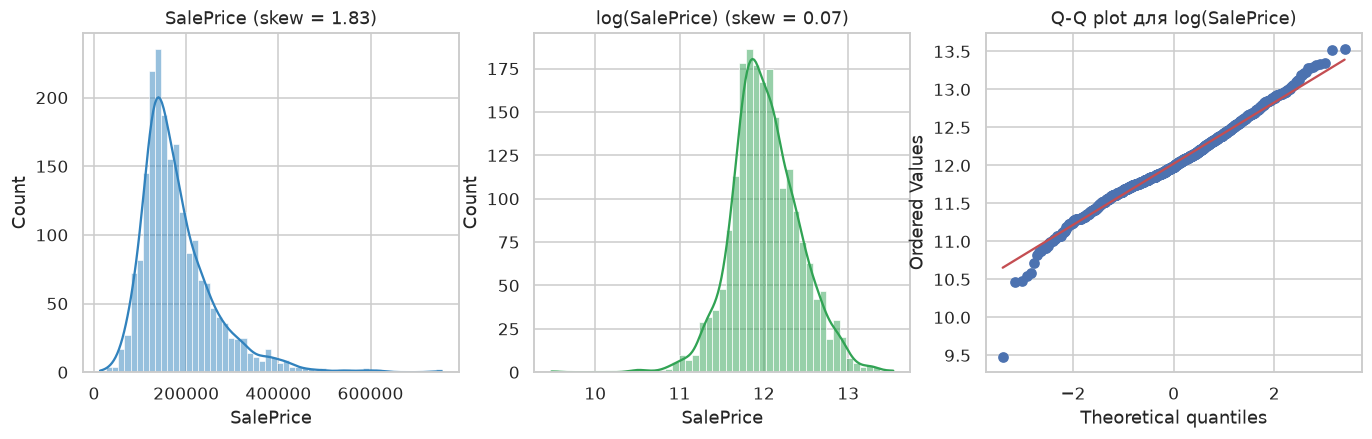

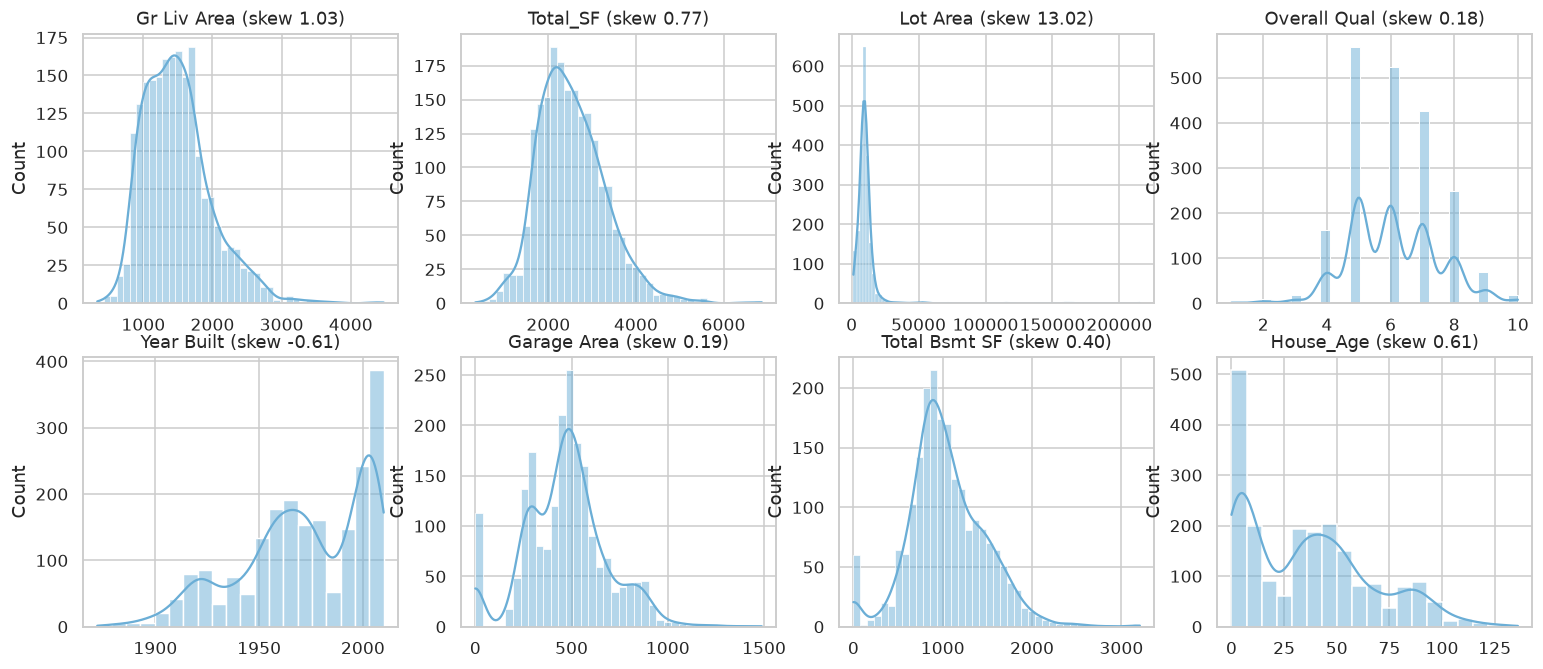

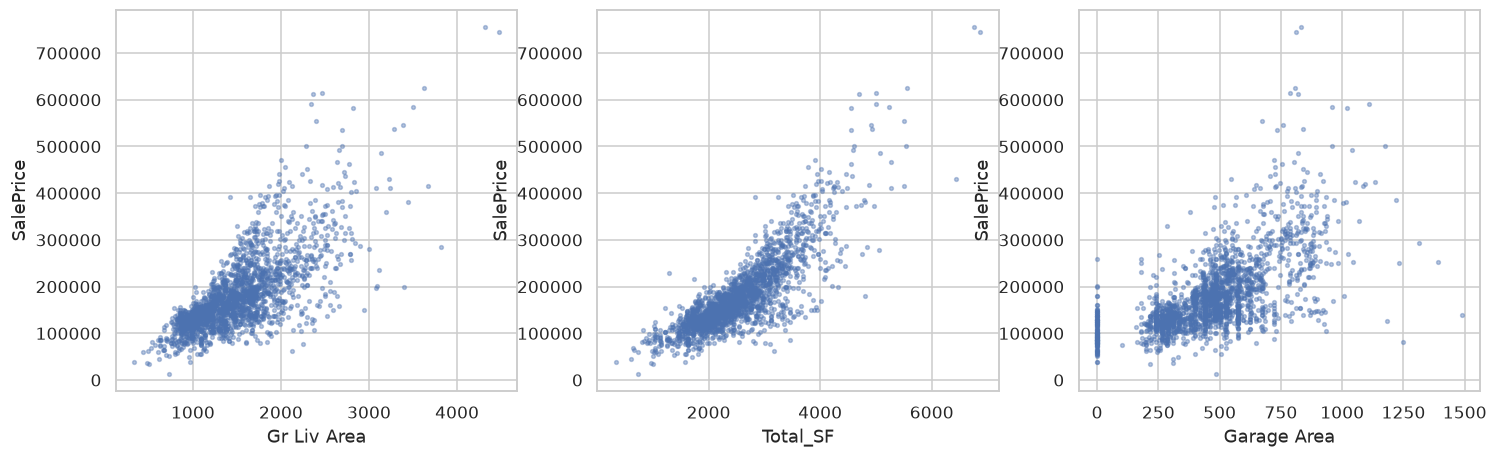

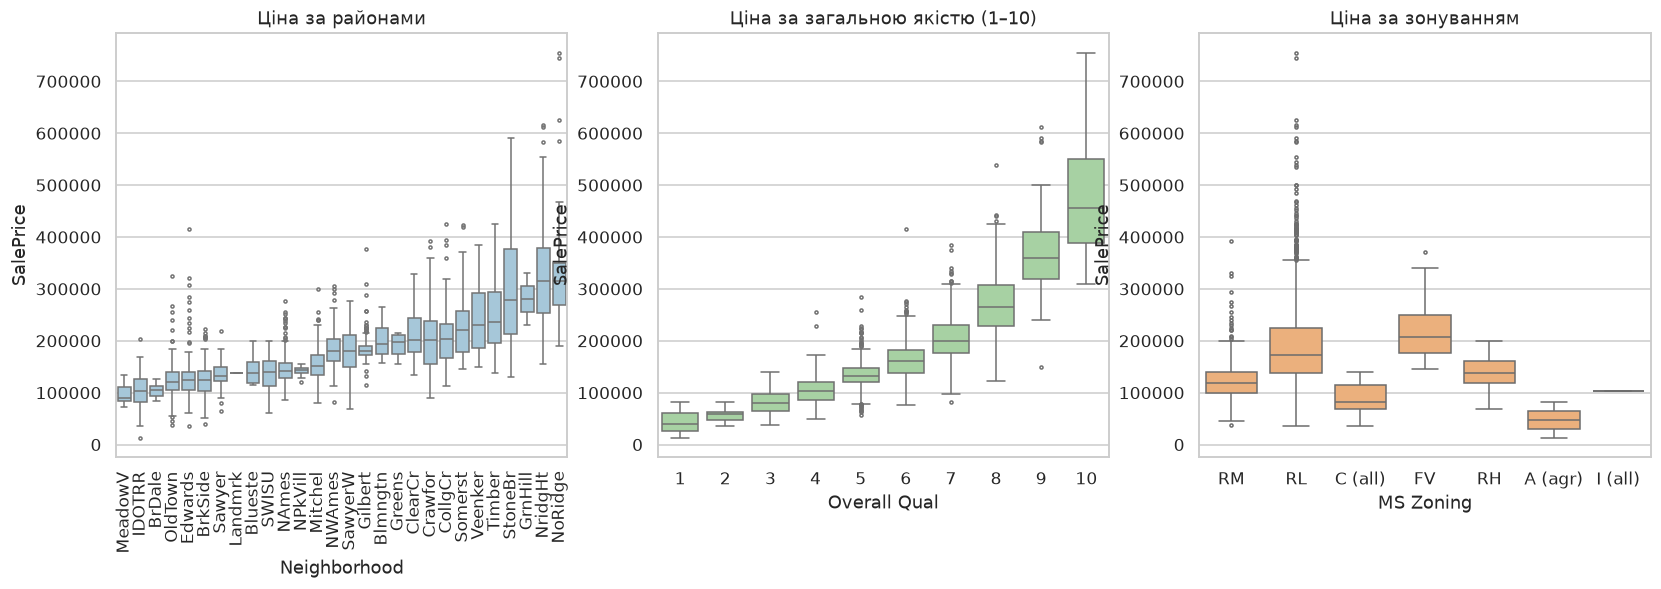

In [19]:
desc = train[NUM_COLS + [TARGET]].describe().T
desc["skew"] = train[NUM_COLS + [TARGET]].skew()
desc["kurtosis"] = train[NUM_COLS + [TARGET]].kurt()
desc["pct_zero"] = (train[NUM_COLS + [TARGET]] == 0).mean() * 100
desc.round(3).to_csv(TAB / "03_numeric_describe.csv")
print(desc[["mean", "50%", "std", "min", "max", "skew"]].round(2).to_string())

cat_desc = pd.DataFrame({
    "n_levels": train[NOM_COLS].nunique(),
    "top": train[NOM_COLS].agg(lambda s: s.value_counts().index[0]),
    "top_share_pct": train[NOM_COLS].agg(lambda s: s.value_counts(normalize=True).iloc[0] * 100).round(1),
}).sort_values("n_levels", ascending=False)
cat_desc.to_csv(TAB / "04_categorical_describe.csv")
print(cat_desc.to_string())

# --- цільова змінна
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(train[TARGET], kde=True, ax=ax[0], color="#3182bd")
ax[0].set_title(f"SalePrice (skew = {train[TARGET].skew():.2f})")
sns.histplot(np.log(train[TARGET]), kde=True, ax=ax[1], color="#31a354")
ax[1].set_title(f"log(SalePrice) (skew = {np.log(train[TARGET]).skew():.2f})")
stats.probplot(np.log(train[TARGET]), dist="norm", plot=ax[2])
ax[2].set_title("Q-Q plot для log(SalePrice)")
savefig("02_target_distribution.png")
display(Image(filename=str(FIG / "02_target_distribution.png")))

# --- основні числові ознаки
main_num = ["Gr Liv Area", "Total_SF", "Lot Area", "Overall Qual", "Year Built",
            "Garage Area", "Total Bsmt SF", "House_Age"]
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for a, c in zip(axes.ravel(), main_num):
    sns.histplot(train[c], kde=True, ax=a, color="#6baed6")
    a.set_title(f"{c} (skew {train[c].skew():.2f})")
    a.set_xlabel("")
savefig("03_numeric_distributions.png")
display(Image(filename=str(FIG / "03_numeric_distributions.png")))

# --- ціна vs головні ознаки
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for a, c in zip(axes, ["Gr Liv Area", "Total_SF", "Garage Area"]):
    a.scatter(train[c], train[TARGET], s=6, alpha=0.4)
    a.set_xlabel(c); a.set_ylabel("SalePrice")
savefig("04_price_scatter.png")
display(Image(filename=str(FIG / "04_price_scatter.png")))

# --- категоріальні
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order = train.groupby("Neighborhood")[TARGET].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y=TARGET, order=order, ax=axes[0], color="#9ecae1", fliersize=2)
axes[0].tick_params(axis="x", rotation=90); axes[0].set_title("Ціна за районами")
sns.boxplot(data=train, x="Overall Qual", y=TARGET, ax=axes[1], color="#a1d99b", fliersize=2)
axes[1].set_title("Ціна за загальною якістю (1–10)")
sns.boxplot(data=train, x="MS Zoning", y=TARGET, ax=axes[2], color="#fdae6b", fliersize=2)
axes[2].set_title("Ціна за зонуванням")
savefig("05_categorical_vs_price.png")
display(Image(filename=str(FIG / "05_categorical_vs_price.png")))

# 5. Пайплайн передобробки (будується один раз, використовується скрізь)
* **Імпутація** — параметри лише з train:
`Lot Frontage` → медіана по `Neighborhood` (сусідні ділянки схожі), решта числових → медіана,
категоріальні → мода.
* **Log1p** для сильно скошених невід'ємних неперервних ознак (список визначено за skew на train).
* **Масштабування** — `StandardScaler` (mean/std з train).
* **Кодування номінальних**: ≤10 рівнів → One-Hot; >10 рівнів → Target Encoding
(`sklearn.TargetEncoder`, внутрішня крос-фіт схема проти витоку таргету).
* **Невідомі категорії** у val/test: One-Hot → `handle_unknown="infrequent_if_exist"`
(рідкісні та нові рівні потрапляють в одну колонку `infrequent`, а якщо такої колонки немає — рядок усіх нулів);
Target Encoding → глобальне середнє таргету.

In [20]:
class LotFrontageImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.by_nb_ = X.groupby("Neighborhood")["Lot Frontage"].median()
        self.global_ = X["Lot Frontage"].median()
        return self

    def transform(self, X):
        X = X.copy()
        fill = X["Neighborhood"].map(self.by_nb_).fillna(self.global_)
        X["Lot Frontage"] = X["Lot Frontage"].fillna(fill)
        return X


# які числові ознаки логарифмувати: skew > 0.75, min >= 0, "неперервні" (>10 унікальних)
_sk = train[NUM_COLS].skew()
LOG_COLS = [c for c in NUM_COLS
            if _sk[c] > 0.75 and train[c].min() >= 0 and train[c].nunique() > 10]
print("Ознаки для log1p:", LOG_COLS)

HIGH_CARD = 10


def build_preprocessor(num_sel, nom_sel):
    log_sel = [c for c in num_sel if c in LOG_COLS]
    lin_sel = [c for c in num_sel if c not in LOG_COLS]
    low = [c for c in nom_sel if train[c].nunique() <= HIGH_CARD]
    high = [c for c in nom_sel if train[c].nunique() > HIGH_CARD]

    tf = []
    if log_sel:
        tf.append(("num_log", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("sc", StandardScaler())]), log_sel))
    if lin_sel:
        tf.append(("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())]), lin_sel))
    if low:
        tf.append(("onehot", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01,
                                 sparse_output=False))]), low))
    if high:
        tf.append(("target", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("te", TargetEncoder(target_type="continuous", smooth="auto", cv=5, random_state=SEED)),
            ("sc", StandardScaler())]), high))
    ct = ColumnTransformer(tf, remainder="drop", verbose_feature_names_out=False)
    ct.set_output(transform="pandas")
    return Pipeline([("lot", LotFrontageImputer()), ("ct", ct)])

Ознаки для log1p: ['Lot Frontage', 'Lot Area', 'Mas Vnr Area', 'BsmtFin SF 2', 'Bsmt Unf SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Misc Val', 'Total_SF', 'Porch_SF']


# 6. Відбір ознак (тільки train)
## 6.1 Числові та ординальні ознаки
Кроки: (a) прибрати майже константні → (b) кореляційний аналіз →
(c) прибрати мультиколінеарні дублі → (d) ранжування трьома незалежними
методами (F-тест/Пірсон, Mutual Information, RFE) → (e) вибір K за
validation-кривою.

Майже константні (прибрано): ['Street', 'Utilities', 'Low Qual Fin SF', '3Ssn Porch', 'Pool Area', 'Pool QC']
                pearson  spearman  abs_pearson
Overall Qual      0.827     0.809        0.827
Total_SF          0.822     0.818        0.822
Gr Liv Area       0.733     0.726        0.733
Exter Qual        0.691     0.689        0.691
Garage Cars       0.680     0.700        0.680
Total_Bath        0.676     0.718        0.676
Kitchen Qual      0.667     0.668        0.667
Total Bsmt SF     0.663     0.616        0.663
Garage Area       0.661     0.662        0.661
Bsmt Qual         0.630     0.686        0.630
1st Flr SF        0.627     0.584        0.627
House_Age        -0.612    -0.674        0.612
Year Built        0.611     0.676        0.611
Garage Finish     0.595     0.623        0.595
Remod_Age        -0.589    -0.602        0.589
Full Bath         0.587     0.641        0.587
Year Remod/Add    0.587     0.599        0.587
Fireplace Qu      0.545     0.542        0.5

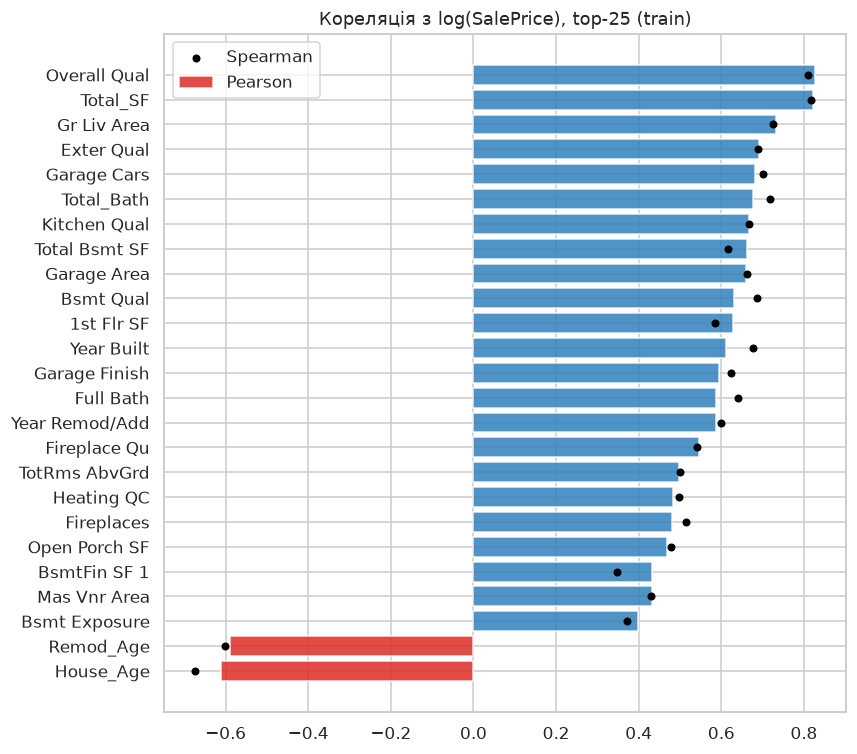

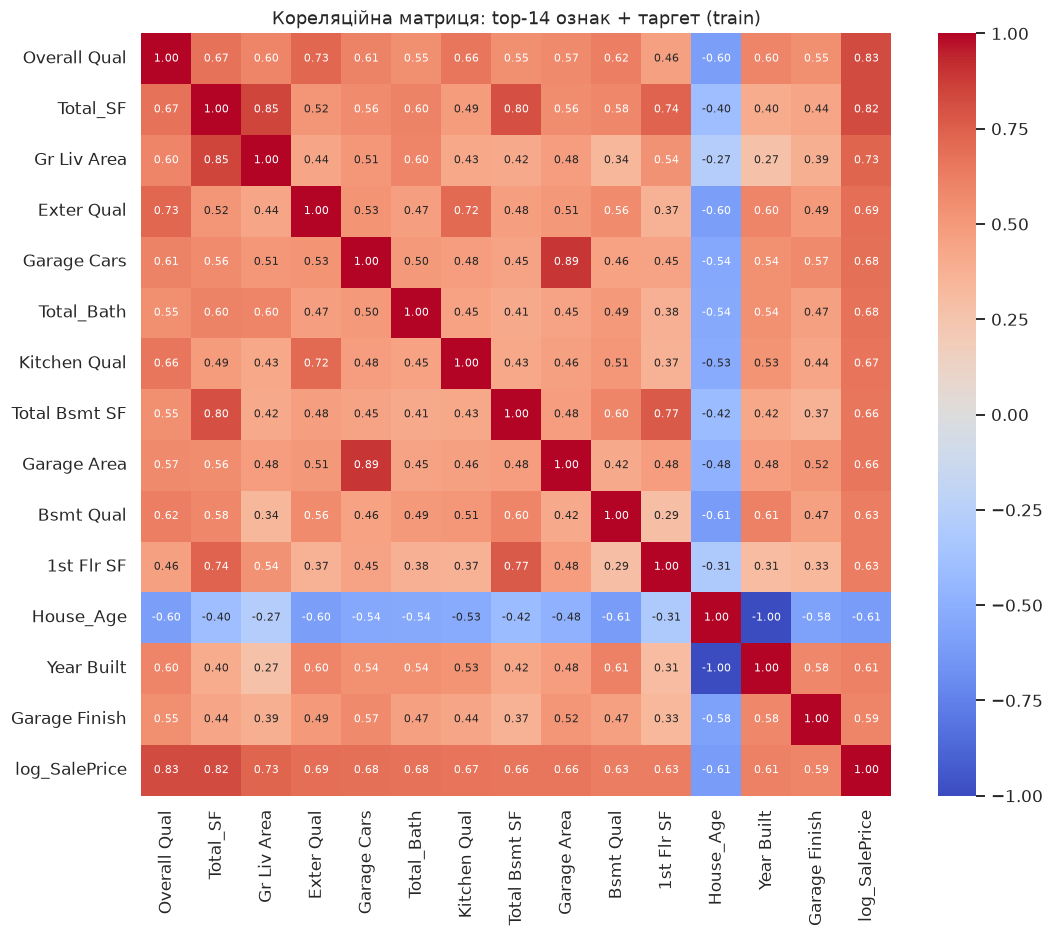


Відкинуто через колінеарність (ознака: (з ким, |r|)):
  Garage Area        ~ Garage Cars        |r|=0.892
  Year Built         ~ House_Age          |r|=0.999
  Year Remod/Add     ~ Remod_Age          |r|=0.998
  Fireplaces         ~ Fireplace Qu       |r|=0.865
  Garage Cond        ~ Garage Qual        |r|=0.949
  BsmtFin SF 2       ~ BsmtFin Type 2     |r|=0.875
                 F_stat    MI  RFE_rank   r_F  r_MI  mean_rank
Overall Qual    4441.19  0.60         1   1.0   2.0       1.33
Total_SF        4255.90  0.69         2   2.0   1.0       1.67
Gr Liv Area     2370.87  0.48         4   3.0   3.0       3.33
Garage Cars     1764.57  0.38         9   5.0   5.0       6.33
House_Age       1223.05  0.38         3  11.0   7.0       7.00
Exter Qual      1872.97  0.33         8   4.0  10.0       7.33
Total Bsmt SF   1608.34  0.42        12   8.0   4.0       8.00
Kitchen Qual    1640.62  0.32        11   7.0  11.0       9.67
Bsmt Qual       1343.72  0.37        24   9.0   8.0      13.67
Fir

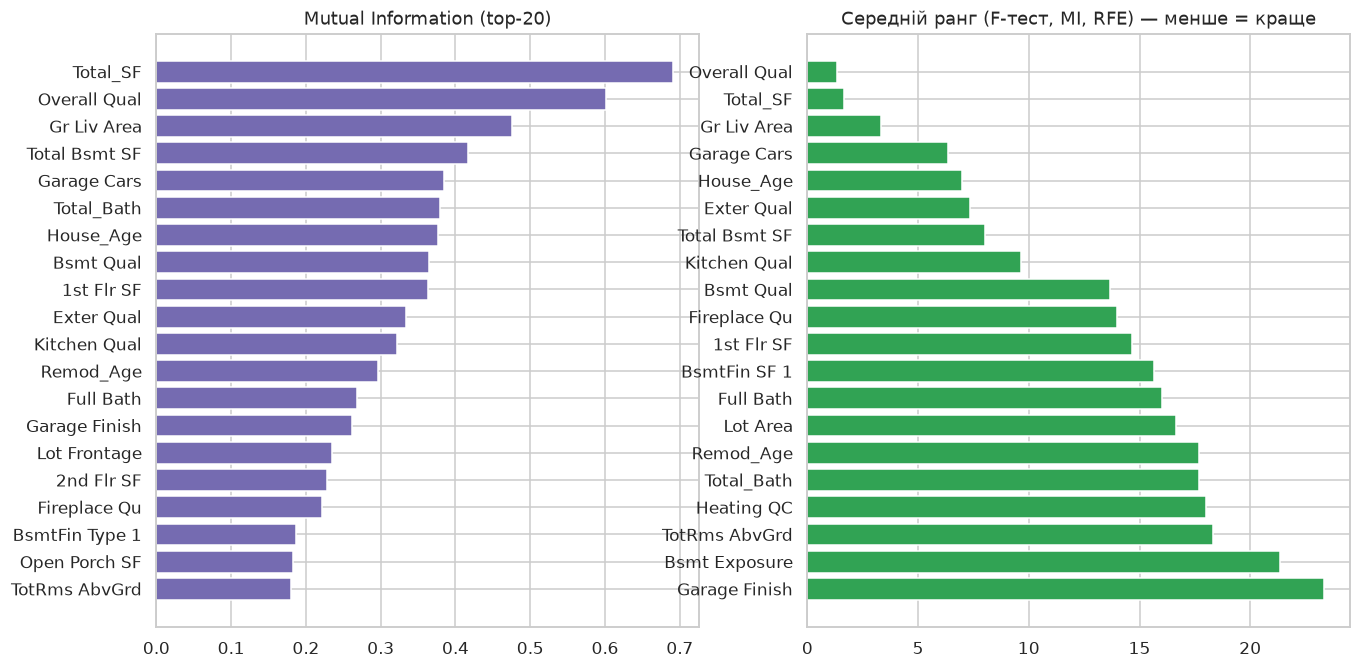


Найкращий val RMSE = 0.1433; обрано K = 21 (у межах 3% від оптимуму)


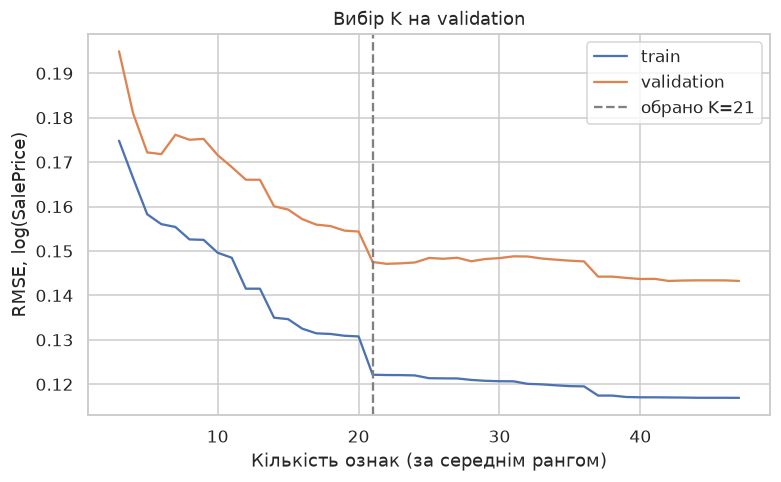

Обрані числові: ['Overall Qual', 'Total_SF', 'Gr Liv Area', 'Garage Cars', 'House_Age', 'Exter Qual', 'Total Bsmt SF', 'Kitchen Qual', 'Bsmt Qual', 'Fireplace Qu', '1st Flr SF', 'BsmtFin SF 1', 'Full Bath', 'Lot Area', 'Total_Bath', 'Remod_Age', 'Heating QC', 'TotRms AbvGrd', 'Bsmt Exposure', 'Garage Finish', 'Overall Cond']


In [21]:
top_share = train[NUM_COLS].apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
near_const = top_share[top_share > 0.98].index.tolist()
print("Майже константні (прибрано):", near_const)
cand_num = [c for c in NUM_COLS if c not in near_const]

prep_num = build_preprocessor(cand_num, [])
Xtr_n = prep_num.fit_transform(train, y_tr)      # fit ТІЛЬКИ на train
Xva_n = prep_num.transform(val)

# (b) кореляційний аналіз з log(SalePrice)
corr = pd.DataFrame({
    "pearson": Xtr_n.corrwith(y_tr),
    "spearman": Xtr_n.corrwith(y_tr, method="spearman"),
})
corr["abs_pearson"] = corr["pearson"].abs()
corr = corr.sort_values("abs_pearson", ascending=False)
corr.round(3).to_csv(TAB / "05_correlation_with_target.csv")
print(corr.head(20).round(3).to_string())

top = corr.head(25).sort_values("pearson")
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index, top["pearson"], color=np.where(top["pearson"] > 0, "#3182bd", "#de2d26"), alpha=.85, label="Pearson")
ax.scatter(top["spearman"], top.index, color="black", s=18, zorder=3, label="Spearman")
ax.set_title("Кореляція з log(SalePrice), top-25 (train)"); ax.legend()
savefig("06_correlation_with_target.png")
display(Image(filename=str(FIG / "06_correlation_with_target.png")))

hm_cols = corr.head(14).index.tolist()
hm = Xtr_n[hm_cols].assign(log_SalePrice=y_tr.values).corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Кореляційна матриця: top-14 ознак + таргет (train)")
savefig("07_correlation_heatmap.png")
display(Image(filename=str(FIG / "07_correlation_heatmap.png")))

# (c) мультиколінеарність: у парі з |r|>0.85 лишаємо ту, що сильніше корелює з таргетом
C = Xtr_n.corr().abs()
kept, dropped = [], {}
for f in corr.index:                       # від найсильнішої до найслабшої
    partner = next((k for k in kept if C.loc[f, k] > 0.85), None)
    if partner is None:
        kept.append(f)
    else:
        dropped[f] = (partner, round(C.loc[f, partner], 3))
print("\nВідкинуто через колінеарність (ознака: (з ким, |r|)):")
for k, v in dropped.items():
    print(f"  {k:18s} ~ {v[0]:18s} |r|={v[1]}")

# (d) три методи
Xk = Xtr_n[kept]
discrete_mask = np.array([train[c].nunique() <= 15 and (train[c].dropna() % 1 == 0).all() for c in kept])
rank = pd.DataFrame(index=kept)
f_stat, _ = f_regression(Xk, y_tr)
rank["F_stat"] = f_stat                                        # SelectKBest(f_regression)
rank["MI"] = mutual_info_regression(Xk, y_tr, discrete_features=discrete_mask,
                                    n_neighbors=5, random_state=SEED)
rfe = RFE(Ridge(alpha=10), n_features_to_select=1, step=1).fit(Xk, y_tr)
rank["RFE_rank"] = rfe.ranking_
rank["r_F"] = rank["F_stat"].rank(ascending=False)
rank["r_MI"] = rank["MI"].rank(ascending=False)
rank["mean_rank"] = rank[["r_F", "r_MI", "RFE_rank"]].mean(axis=1)
rank = rank.sort_values("mean_rank")
rank.round(3).to_csv(TAB / "06_numeric_feature_ranking.csv")
print(rank.head(25).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
r1 = rank.sort_values("MI").tail(20)
axes[0].barh(r1.index, r1["MI"], color="#756bb1"); axes[0].set_title("Mutual Information (top-20)")
r2 = rank.sort_values("mean_rank", ascending=False).tail(20)
axes[1].barh(r2.index, r2["mean_rank"], color="#31a354")
axes[1].set_title("Середній ранг (F-тест, MI, RFE) — менше = краще")
savefig("08_feature_ranking.png")
display(Image(filename=str(FIG / "08_feature_ranking.png")))

# (e) скільки ознак брати — за якістю на validation (ridge, RMSE у лог-шкалі)
ks = list(range(3, len(rank) + 1))
curve = []
for k in ks:
    cols = rank.index[:k]
    mdl = Ridge(alpha=1.0).fit(Xtr_n[cols], y_tr)
    curve.append((k, rmse(y_tr, mdl.predict(Xtr_n[cols])), rmse(y_va, mdl.predict(Xva_n[cols]))))
curve = pd.DataFrame(curve, columns=["K", "train_rmse", "val_rmse"])
best = curve["val_rmse"].min()
TOL = 0.03                                                            # допустима втрата якості vs оптимум
K_NUM = int(curve.loc[curve["val_rmse"] <= best * (1 + TOL), "K"].min())   # найменше K у межах 3% від найкращого
print(f"\nНайкращий val RMSE = {best:.4f}; обрано K = {K_NUM} (у межах {TOL:.0%} від оптимуму)")
curve.round(4).to_csv(TAB / "07_k_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve.K, curve.train_rmse, label="train"); ax.plot(curve.K, curve.val_rmse, label="validation")
ax.axvline(K_NUM, color="gray", ls="--", label=f"обрано K={K_NUM}")
ax.set_xlabel("Кількість ознак (за середнім рангом)"); ax.set_ylabel("RMSE, log(SalePrice)")
ax.set_title("Вибір K на validation"); ax.legend()
savefig("09_k_curve.png")
display(Image(filename=str(FIG / "09_k_curve.png")))

SEL_NUM = rank.index[:K_NUM].tolist()
print("Обрані числові:", SEL_NUM)

## 6.2 Номінальні ознаки
 * **ε² (epsilon-squared)** — скоригована частка дисперсії `log(SalePrice)`, що пояснюється групами
(аналог R² для ANOVA; поправка на кількість рівнів, щоб ознаки з багатьма рівнями не отримували штучну перевагу);
* **Mutual Information** між кодами категорій і таргетом;
* фільтри: домінантна категорія >98% → відкидаємо; пара ознак із Cramér's V > 0.8 → лишаємо кращу.
Поріг відбору: ε² ≥ 0.10 (середній–великий ефект).

                n_levels  top_share   eps2     MI  near_const
Neighborhood          28      0.151  0.585  0.582       False
MS SubClass           15      0.375  0.315  0.298       False
Foundation             6      0.444  0.312  0.224       False
Garage Type            7      0.600  0.312  0.228       False
Exterior 1st          16      0.347  0.202  0.186       False
MS Zoning              7      0.774  0.191  0.131       False
Mas Vnr Type           5      0.604  0.188  0.113       False
Exterior 2nd          16      0.344  0.183  0.185       False
Sale Condition         6      0.822  0.129  0.091       False
Sale Type             10      0.863  0.121  0.091       False
Electrical             4      0.916  0.090  0.048       False
House Style            8      0.512  0.078  0.097       False
Roof Style             6      0.795  0.049  0.033       False
Bldg Type              5      0.820  0.046  0.058       False
Condition 1            9      0.858  0.044  0.028       False
Fence   

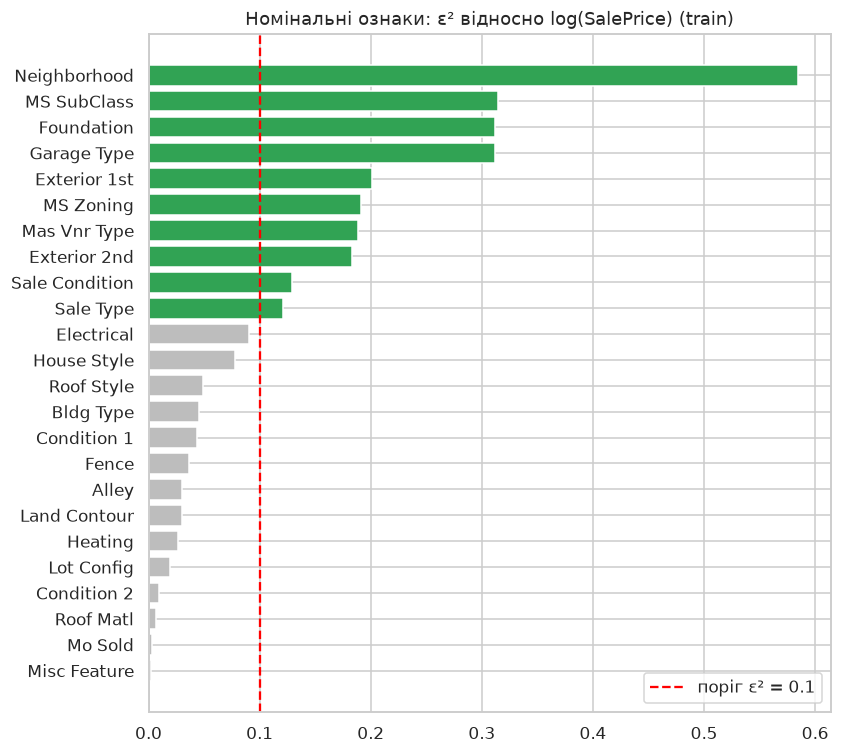

In [22]:
def eps_squared(x, y):
    g = pd.DataFrame({"x": x.values, "y": y.values}).groupby("x")["y"]
    n, k = len(y), g.ngroups
    ssb = (g.count() * (g.mean() - y.mean()) ** 2).sum()
    sst = ((y - y.mean()) ** 2).sum()
    return float(max(0.0, (ssb - (k - 1) * (sst - ssb) / (n - k)) / sst))


def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = chi2_contingency(t, correction=False)[0]
    n = t.values.sum(); r, k = t.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return float(np.sqrt(phi2 / max(1e-9, min(kc - 1, rc - 1))))


tr_nom = train[NOM_COLS].apply(lambda s: s.fillna(s.mode()[0]))
codes = OrdinalEncoder().fit_transform(tr_nom)
nom = pd.DataFrame({
    "n_levels": tr_nom.nunique(),
    "top_share": tr_nom.apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    "eps2": [eps_squared(tr_nom[c], y_tr) for c in NOM_COLS],
    "MI": mutual_info_regression(codes, y_tr, discrete_features=True, random_state=SEED),
}, index=NOM_COLS).sort_values("eps2", ascending=False)
nom["near_const"] = nom["top_share"] > 0.98
nom.round(3).to_csv(TAB / "08_nominal_scores.csv")
print(nom.round(3).to_string())

THRESH = 0.10
cand_nom = nom[(nom.eps2 >= THRESH) & (~nom.near_const)].index.tolist()
sel_nom, dropped_nom = [], {}
for f in cand_nom:                                    # від найсильнішої
    partner = next((k for k in sel_nom if cramers_v(tr_nom[f], tr_nom[k]) > 0.8), None)
    if partner is None:
        sel_nom.append(f)
    else:
        dropped_nom[f] = (partner, round(cramers_v(tr_nom[f], tr_nom[partner]), 2))
SEL_NOM = sel_nom
print("\nОбрані номінальні:", SEL_NOM)
print("Відкинуто як дублі (Cramér's V > 0.8):", dropped_nom)

fig, ax = plt.subplots(figsize=(8, 8))
n2 = nom.sort_values("eps2").tail(25)
ax.barh(n2.index, n2["eps2"], color=np.where(n2.index.isin(SEL_NOM), "#31a354", "#bdbdbd"))
ax.axvline(THRESH, color="red", ls="--", label=f"поріг ε² = {THRESH}")
ax.set_title("Номінальні ознаки: ε² відносно log(SalePrice) (train)"); ax.legend()
savefig("10_nominal_scores.png")
display(Image(filename=str(FIG / "10_nominal_scores.png")))

# 7. Кодування категорій: невідомі рівні у validation/test
Перевіряємо, чи справді трапляються категорії, яких немає в train.

In [23]:
rows = []
for c in NOM_COLS:
    seen = set(train[c].dropna().unique())
    for name, part in (("val", val), ("test", test)):
        new = part.loc[~part[c].isin(seen) & part[c].notna(), c]
        if len(new):
            rows.append({"feature": c, "split": name, "unseen_levels": sorted(new.unique()),
                         "rows_affected": len(new), "selected": c in SEL_NOM})
unseen = pd.DataFrame(rows)
unseen.to_csv(TAB / "09_unseen_categories.csv", index=False)
print(unseen.to_string() if len(unseen) else "Невідомих категорій немає")

        feature split              unseen_levels  rows_affected  selected
0   MS SubClass  test                      [150]              1      True
1   Condition 2  test                     [RRAe]              1     False
2     Roof Matl  test  [ClyTile, Membran, Metal]              3     False
3  Exterior 2nd   val                    [Other]              1      True
4       Heating   val                    [Floor]              1     False
5    Electrical   val                      [Mix]              1     False
6  Misc Feature   val                     [Elev]              1     False
7  Misc Feature  test                     [TenC]              1     False


# 8. Фінальний препроцесор та порівняння наборів ознак на validation

In [24]:
ALL_NUM = cand_num
ALL_NOM = [c for c in NOM_COLS if not nom.loc[c, "near_const"]]

sets = {
    "A: усі ознаки": (ALL_NUM, ALL_NOM),
    "B: відібрані числові": (SEL_NUM, []),
    "C: відібрані числові + номінальні": (SEL_NUM, SEL_NOM),
}
results = []
for name, (ns, cs) in sets.items():
    pp = build_preprocessor(ns, cs)
    Xt, Xv = pp.fit_transform(train, y_tr), pp.transform(val)
    for mname, mdl in (("Ridge", Ridge(alpha=3.0)),
                       ("HistGB", HistGradientBoostingRegressor(random_state=SEED, max_iter=300, learning_rate=0.05))):
        mdl.fit(Xt, y_tr)
        results.append({"набір": name, "n_features_after_encoding": Xt.shape[1], "модель": mname,
                        "val_RMSE(log)": rmse(y_va, mdl.predict(Xv)),
                        "val_R2": r2_score(y_va, mdl.predict(Xv))})
res = pd.DataFrame(results)
res.round(4).to_csv(TAB / "10_validation_comparison.csv", index=False)
print(res.round(4).to_string())

                               набір  n_features_after_encoding  модель  val_RMSE(log)  val_R2
0                      A: усі ознаки                        130   Ridge         0.1347  0.8933
1                      A: усі ознаки                        130  HistGB         0.1199  0.9156
2               B: відібрані числові                         21   Ridge         0.1474  0.8723
3               B: відібрані числові                         21  HistGB         0.1397  0.8853
4  C: відібрані числові + номінальні                         53   Ridge         0.1391  0.8862
5  C: відібрані числові + номінальні                         53  HistGB         0.1286  0.9027


# 9. Фінальні дані: fit на train → transform train/val/test

Форма: (2049, 53) (440, 53) (440, 53)
               train_mean  train_std  val_mean  val_std  test_mean  test_std
Total_SF              0.0        1.0     0.036    1.010     -0.014     1.001
Gr Liv Area          -0.0        1.0     0.049    1.016     -0.035     1.027
1st Flr SF            0.0        1.0    -0.001    1.007     -0.018     1.038
Lot Area              0.0        1.0     0.044    0.940      0.015     0.924
Overall Qual          0.0        1.0    -0.041    1.064      0.008     1.040
Garage Cars          -0.0        1.0     0.013    1.037     -0.047     0.959
House_Age            -0.0        1.0     0.004    1.030      0.015     1.027
Exter Qual           -0.0        1.0    -0.013    0.993      0.011     1.024
Total Bsmt SF         0.0        1.0     0.029    1.081      0.018     1.087
Kitchen Qual          0.0        1.0    -0.002    1.065      0.075     1.067
Bsmt Qual             0.0        1.0    -0.007    0.986      0.025     0.915
Fireplace Qu         -0.0        1.0  

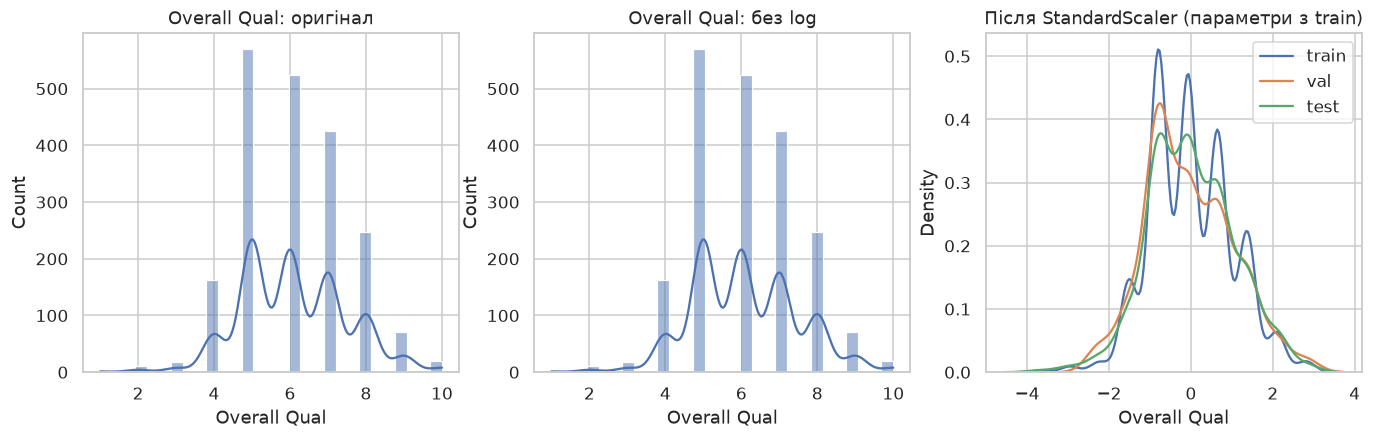


Проба з повністю новими категоріями — форма: (3, 53) | NaN: 0


In [25]:
pre = build_preprocessor(SEL_NUM, SEL_NOM)
X_train = pre.fit_transform(train, y_tr)
X_val = pre.transform(val)
X_test = pre.transform(test)

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert not X_train.isna().any().any() and not X_val.isna().any().any() and not X_test.isna().any().any()
print("Форма:", X_train.shape, X_val.shape, X_test.shape)

# Перевірка масштабування: mean≈0, std≈1 має бути на train; на val/test — ні (і це правильно)
cont = [c for c in X_train.columns if c in SEL_NUM]
chk = pd.DataFrame({
    "train_mean": X_train[cont].mean(), "train_std": X_train[cont].std(),
    "val_mean": X_val[cont].mean(), "val_std": X_val[cont].std(),
    "test_mean": X_test[cont].mean(), "test_std": X_test[cont].std(),
}).round(3)
chk.to_csv(TAB / "11_scaling_check.csv")
print(chk.to_string())

# Демонстрація "до/після" на найсильнішій ознаці
c0 = SEL_NUM[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(train[c0], kde=True, ax=ax[0]); ax[0].set_title(f"{c0}: оригінал")
sns.histplot(np.log1p(train[c0]) if c0 in LOG_COLS else train[c0], kde=True, ax=ax[1])
ax[1].set_title(f"{c0}: після log1p" if c0 in LOG_COLS else f"{c0}: без log")
sns.kdeplot(X_train[c0], ax=ax[2], label="train"); sns.kdeplot(X_val[c0], ax=ax[2], label="val")
sns.kdeplot(X_test[c0], ax=ax[2], label="test"); ax[2].legend()
ax[2].set_title("Після StandardScaler (параметри з train)")
savefig("11_scaling_before_after.png")
display(Image(filename=str(FIG / "11_scaling_before_after.png")))

# Демонстрація: невідомий рівень категорії не ламає пайплайн
probe = test.head(3).copy()
for c in SEL_NOM:
    probe[c] = "UNSEEN_LEVEL"
Xp = pre.transform(probe)
print("\nПроба з повністю новими категоріями — форма:", Xp.shape, "| NaN:", int(Xp.isna().sum().sum()))

# Збереження
X_train.assign(log_SalePrice=y_tr.values).to_csv(OUT / "processed" / "train_processed.csv", index=False)
X_val.assign(log_SalePrice=y_va.values).to_csv(OUT / "processed" / "val_processed.csv", index=False)
X_test.assign(log_SalePrice=y_te.values).to_csv(OUT / "processed" / "test_processed.csv", index=False)
pd.DataFrame({"feature": SEL_NUM, "type": "numeric/ordinal"}).pipe(
    lambda d: pd.concat([d, pd.DataFrame({"feature": SEL_NOM, "type": "nominal"})])
).to_csv(TAB / "12_selected_features.csv", index=False)